In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"E:/RetailPulse_Project/data/cleaned/cleaned_online_retail_II.csv")

In [3]:
df.shape

(779425, 8)

In [4]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [5]:
df.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
779420,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
779421,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
779422,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
779423,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France
779424,581587,POST,POSTAGE,1,2011-12-09 12:50:00,18.00,12680.0,France


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 779425 entries, 0 to 779424
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    779425 non-null  int64  
 1   StockCode    779425 non-null  str    
 2   Description  779425 non-null  str    
 3   Quantity     779425 non-null  int64  
 4   InvoiceDate  779425 non-null  str    
 5   UnitPrice    779425 non-null  float64
 6   CustomerID   779425 non-null  float64
 7   Country      779425 non-null  str    
dtypes: float64(2), int64(2), str(4)
memory usage: 47.6 MB


In [7]:
df.describe()

,InvoiceNo,Quantity,UnitPrice,CustomerID
count,779425.000000,779425.000000,779425.000000,779425.000000
mean,537426.828586,13.489370,3.218488,15320.360461
std,26901.629627,145.855814,29.676140,1695.692775
min,489434.000000,1.000000,0.001000,12346.000000
25%,514483.000000,2.000000,1.250000,13971.000000
50%,536754.000000,6.000000,1.950000,15247.000000
75%,561995.000000,12.000000,3.750000,16794.000000
max,581587.000000,80995.000000,10953.500000,18287.000000


In [8]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [9]:
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

In [10]:
df["Year"] = df["InvoiceDate"].dt.year
df["Month"] = df["InvoiceDate"].dt.month
df["MonthName"] = df["InvoiceDate"].dt.month_name()
df["Day"] = df["InvoiceDate"].dt.day
df["Weekday"] = df["InvoiceDate"].dt.day_name()
df["Hour"] = df["InvoiceDate"].dt.hour

In [11]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Unique Customers:", df["CustomerID"].nunique())
print("Unique Products:", df["StockCode"].nunique())
print("Unique Countries:", df["Country"].nunique())
print("Unique Orders:", df["InvoiceNo"].nunique())

Rows: 779425
Columns: 15
Unique Customers: 5878
Unique Products: 4631
Unique Countries: 41
Unique Orders: 36969


In [12]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
TotalPrice     0
Year           0
Month          0
MonthName      0
Day            0
Weekday        0
Hour           0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(0)

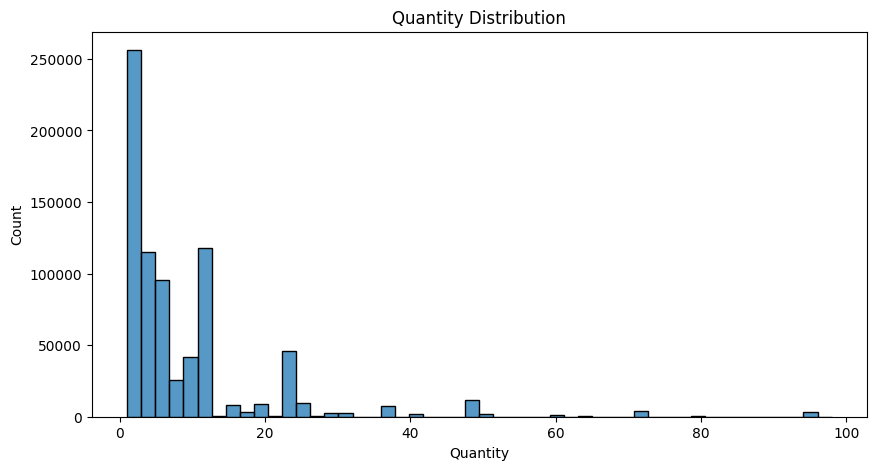

In [14]:
plt.figure(figsize=(10,5))
sns.histplot(df[df["Quantity"] < 100]["Quantity"], bins=50)
plt.title("Quantity Distribution")
plt.xlabel("Quantity")
plt.show()

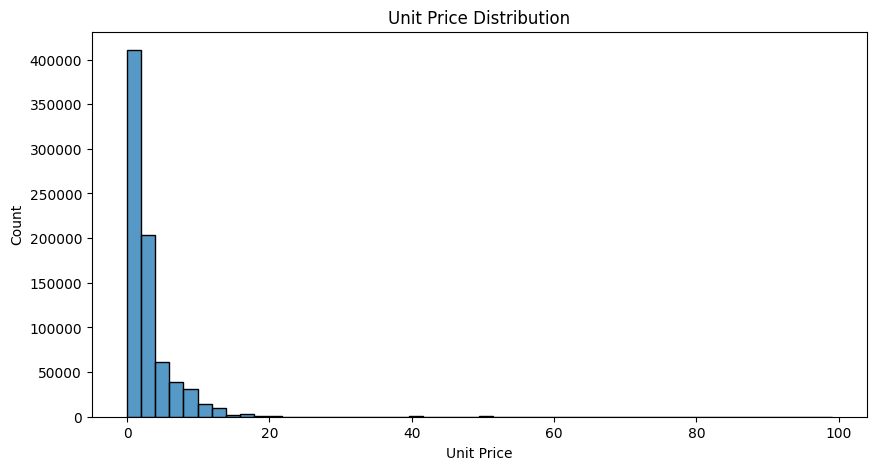

In [15]:
plt.figure(figsize=(10,5))
sns.histplot(df[df["UnitPrice"] < 100]["UnitPrice"], bins=50)
plt.title("Unit Price Distribution")
plt.xlabel("Unit Price")
plt.show()

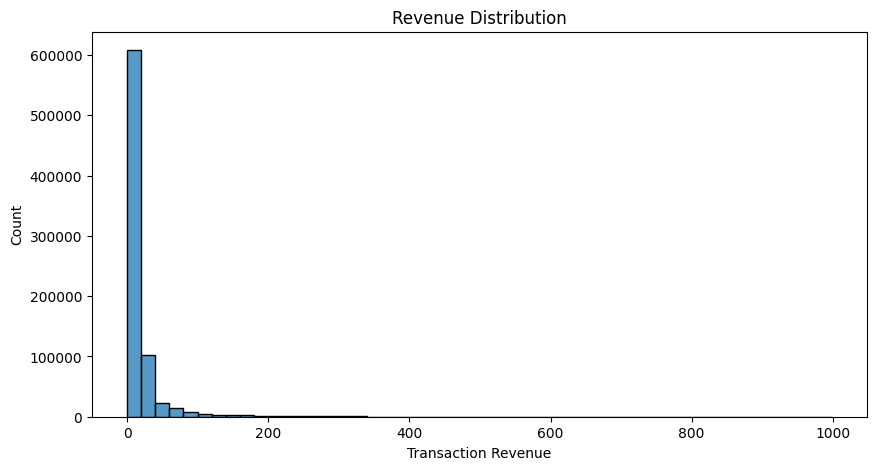

In [16]:
plt.figure(figsize=(10,5))
sns.histplot(df[df["TotalPrice"] < 1000]["TotalPrice"], bins=50)
plt.title("Revenue Distribution")
plt.xlabel("Transaction Revenue")
plt.show()

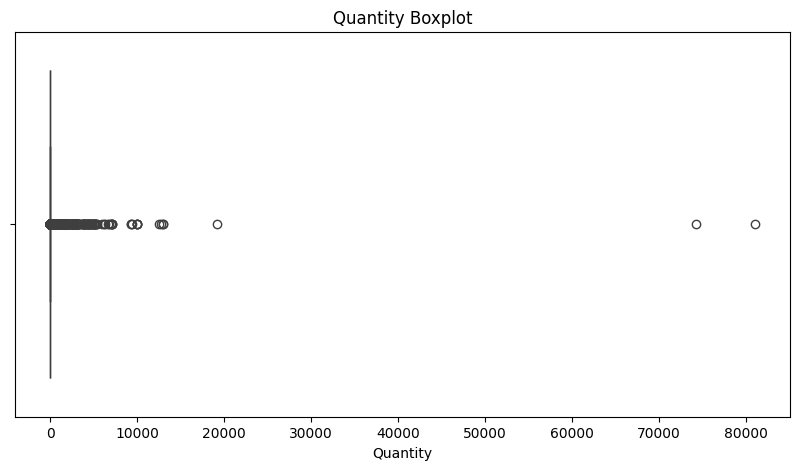

In [17]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df["Quantity"])
plt.title("Quantity Boxplot")
plt.show()

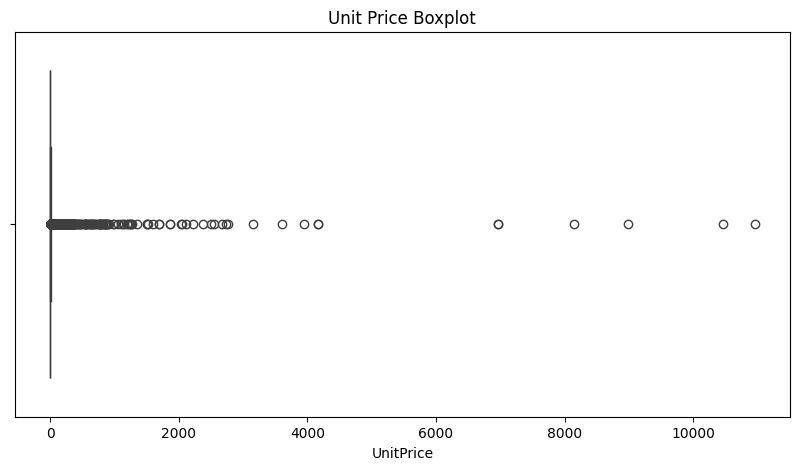

In [18]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df["UnitPrice"])
plt.title("Unit Price Boxplot")
plt.show()

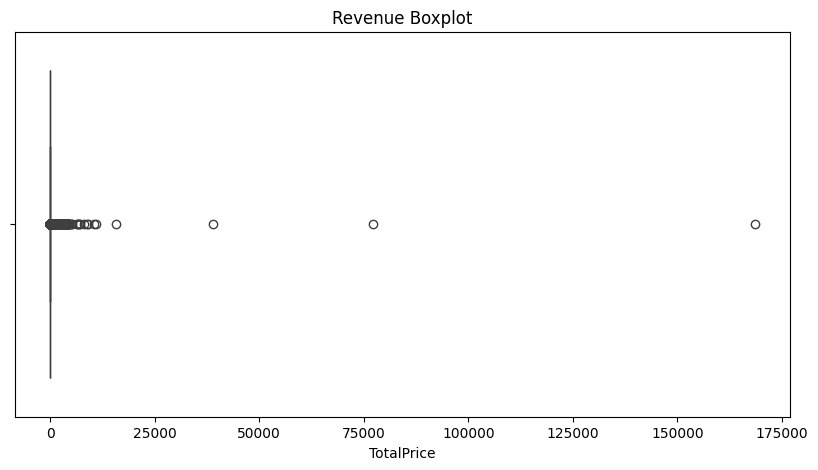

In [19]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df["TotalPrice"])
plt.title("Revenue Boxplot")
plt.show()

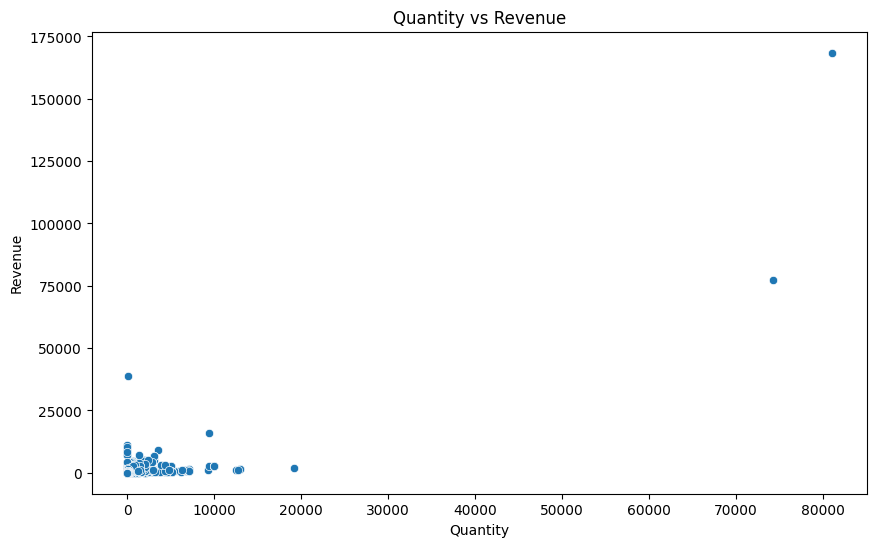

In [20]:
plt.figure(figsize=(10,6))
sns.scatterplot(x="Quantity", y="TotalPrice", data=df)
plt.title("Quantity vs Revenue")
plt.xlabel("Quantity")
plt.ylabel("Revenue")
plt.show()

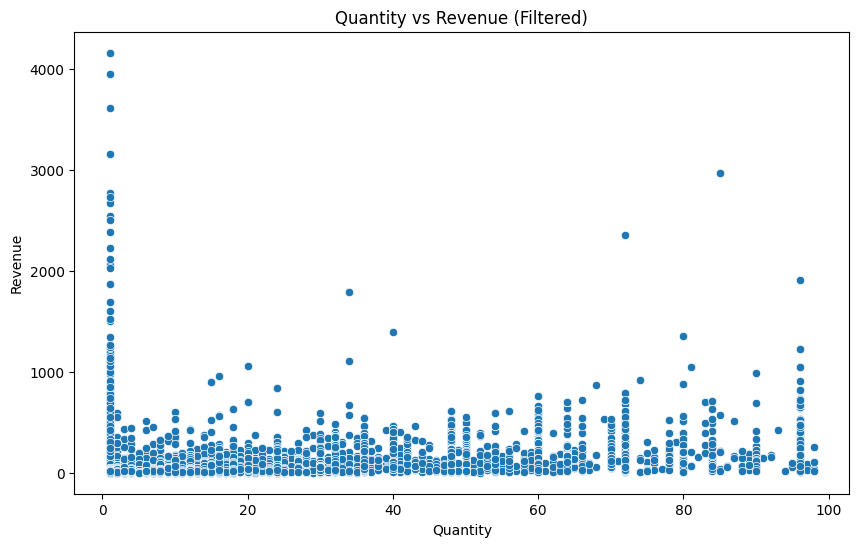

In [21]:
plt.figure(figsize=(10,6))

filtered_df = df[
    (df["Quantity"] < 100) &
    (df["TotalPrice"] < 5000)
]

sns.scatterplot(
    x="Quantity",
    y="TotalPrice",
    data=filtered_df
)

plt.title("Quantity vs Revenue (Filtered)")
plt.xlabel("Quantity")
plt.ylabel("Revenue")
plt.show()

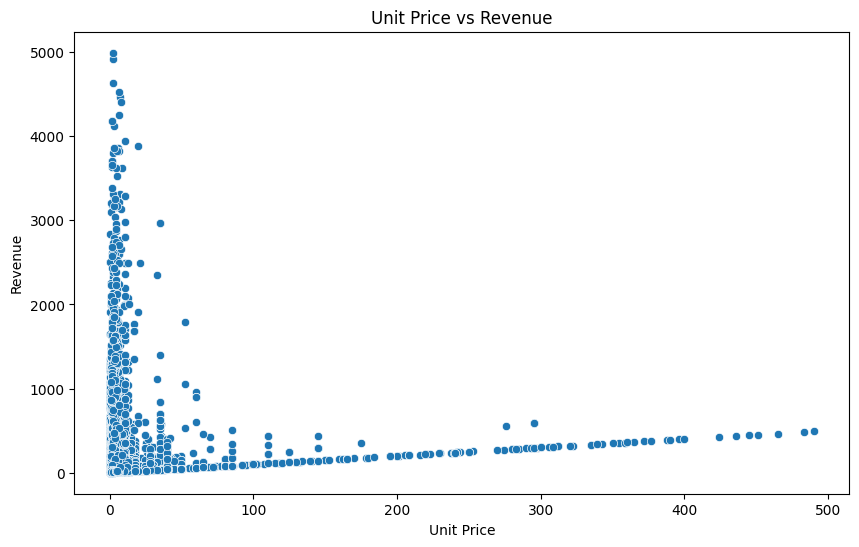

In [22]:
plt.figure(figsize=(10,6))

filtered_df = df[
    (df["UnitPrice"] < 500) &
    (df["TotalPrice"] < 5000)
]

sns.scatterplot(
    x="UnitPrice",
    y="TotalPrice",
    data=filtered_df
)

plt.title("Unit Price vs Revenue")
plt.xlabel("Unit Price")
plt.ylabel("Revenue")
plt.show()

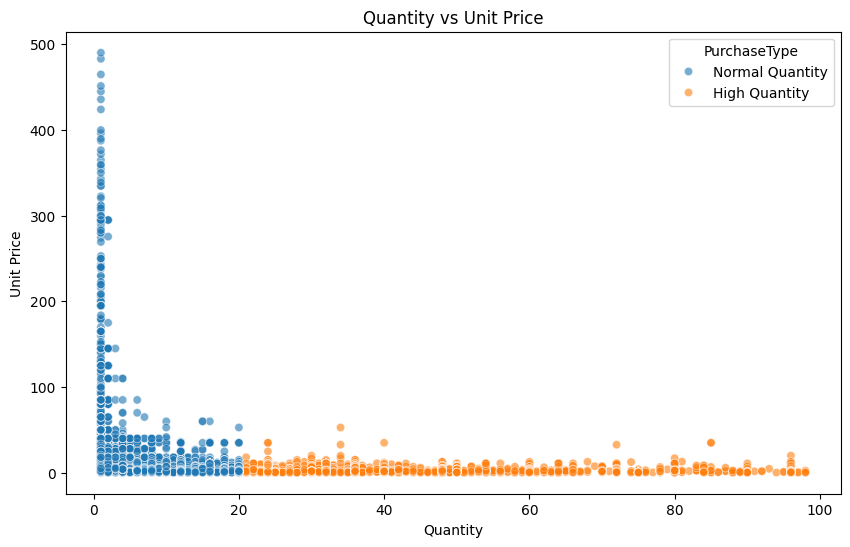

In [24]:
plt.figure(figsize=(10,6))

filtered_df = df[
    (df["Quantity"] < 100) &
    (df["UnitPrice"] < 500)
].copy()

filtered_df["PurchaseType"] = np.where(
    filtered_df["Quantity"] > 20,
    "High Quantity",
    "Normal Quantity"
)

sns.scatterplot(
    x="Quantity",
    y="UnitPrice",
    data=filtered_df,
    hue="PurchaseType",
    alpha=0.6
)

plt.title("Quantity vs Unit Price")
plt.xlabel("Quantity")
plt.ylabel("Unit Price")
plt.show()

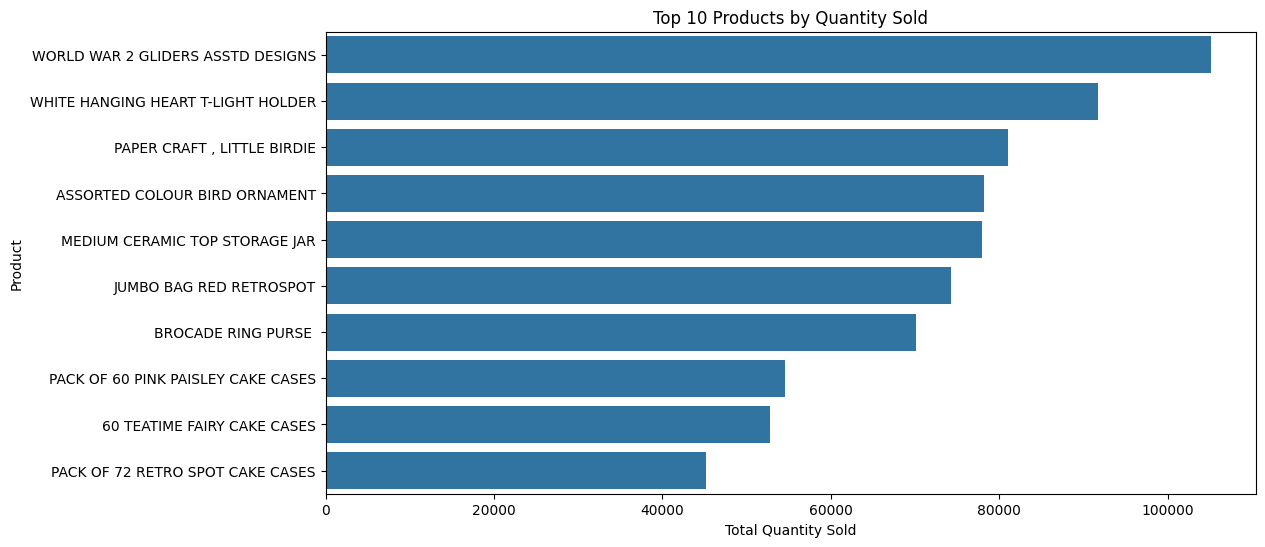

In [25]:
top_products = (
    df.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))
sns.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Total Quantity Sold")
plt.ylabel("Product")
plt.show()

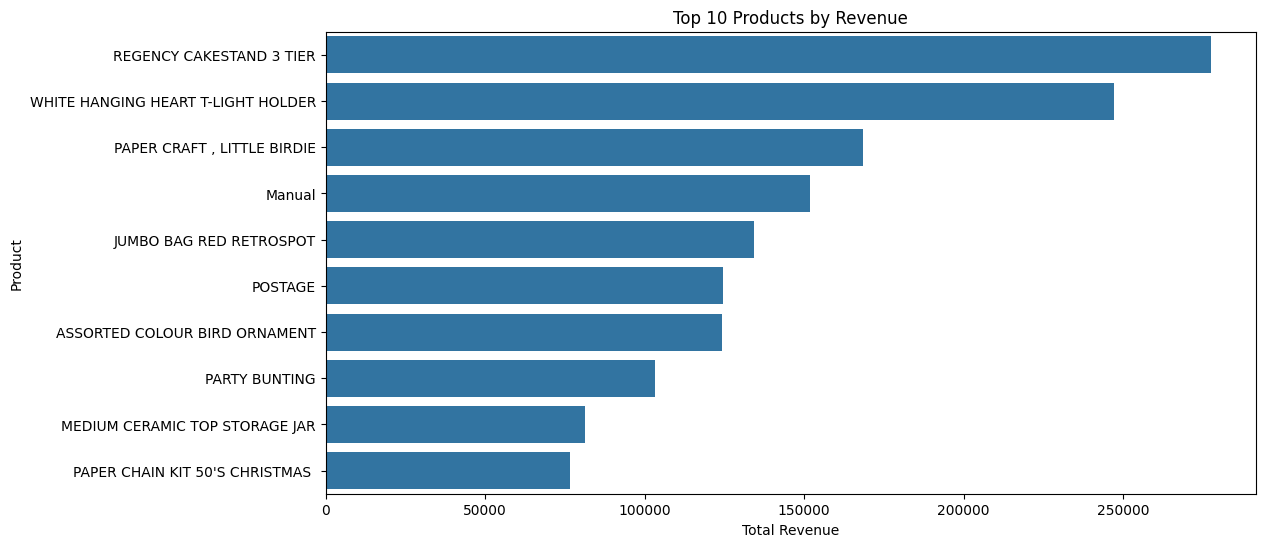

In [26]:
top_revenue_products = (
    df.groupby("Description")["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_revenue_products.values,
    y=top_revenue_products.index
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Product")
plt.show()

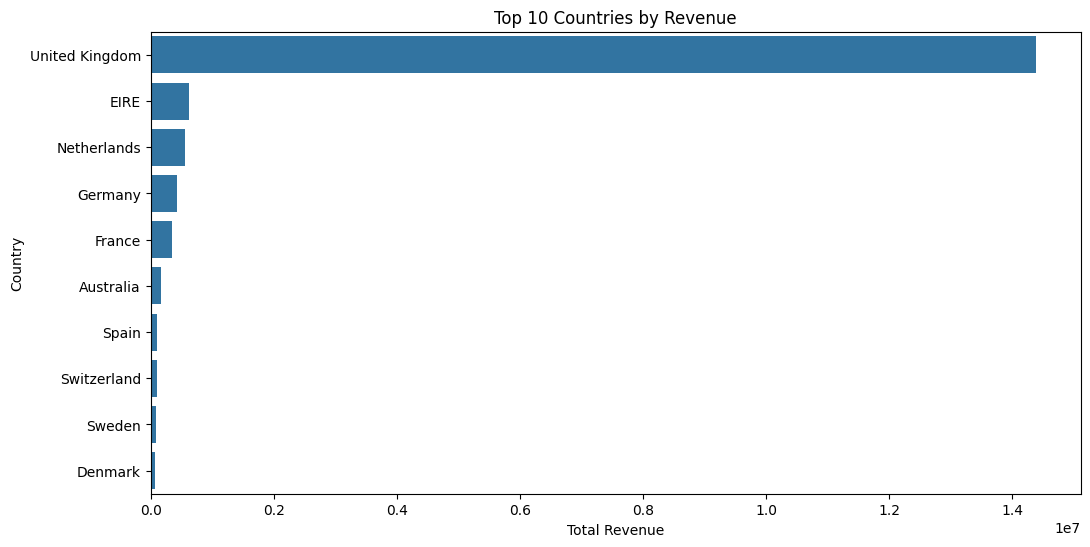

In [27]:
top_countries = (
    df.groupby("Country")["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_countries.values,
    y=top_countries.index
)

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Country")
plt.show()

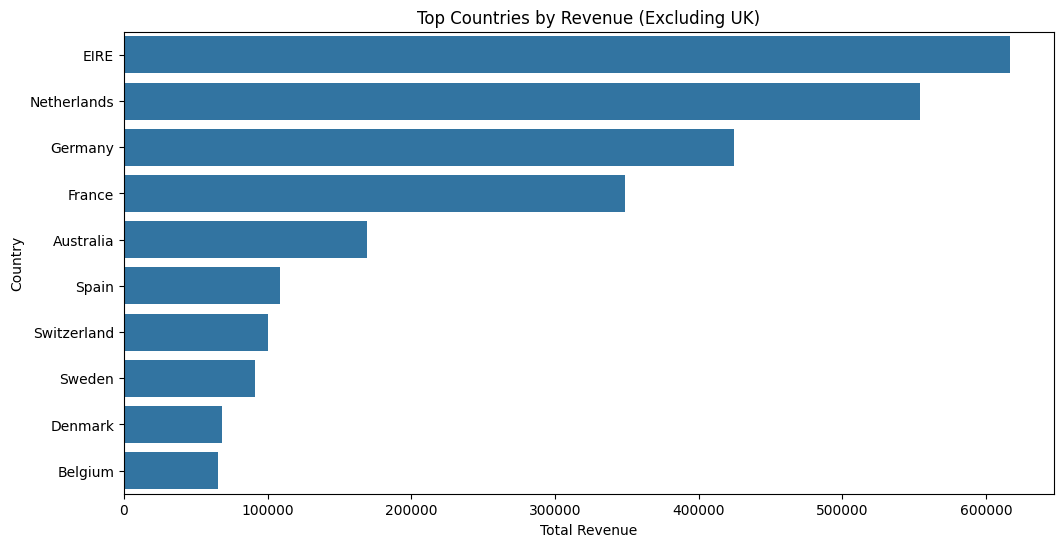

In [28]:
country_revenue_no_uk = (
    df[df["Country"] != "United Kingdom"]
    .groupby("Country")["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=country_revenue_no_uk.values,
    y=country_revenue_no_uk.index
)

plt.title("Top Countries by Revenue (Excluding UK)")
plt.xlabel("Total Revenue")
plt.ylabel("Country")
plt.show()

In [29]:
monthly_sales = (
    df.groupby("MonthName")["TotalPrice"]
    .sum()
)

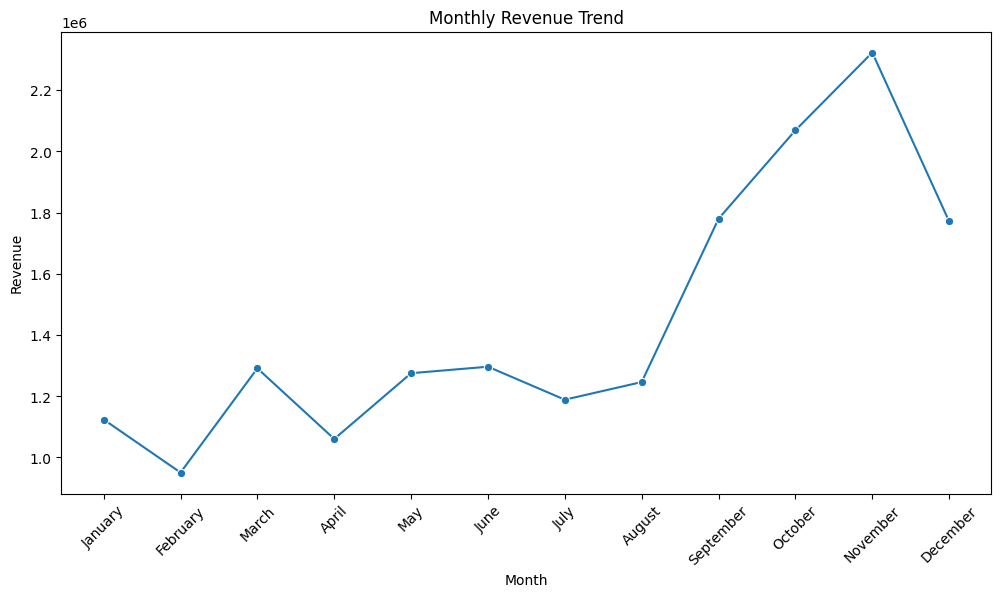

In [30]:
month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

monthly_sales = (
    df.groupby("MonthName")["TotalPrice"]
    .sum()
    .reindex(month_order)
)

plt.figure(figsize=(12,6))

sns.lineplot(
    x=monthly_sales.index,
    y=monthly_sales.values,
    marker="o"
)

plt.xticks(rotation=45)
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

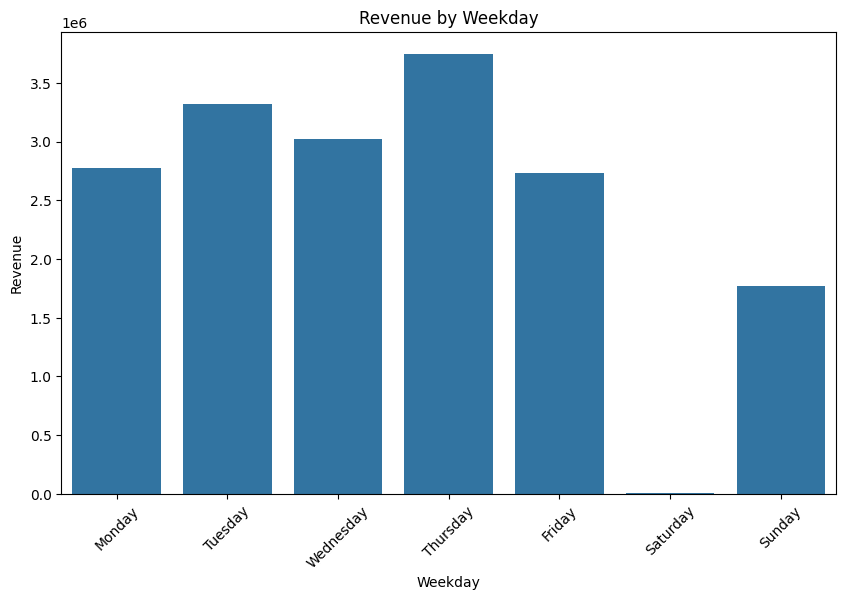

In [31]:
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_sales = (
    df.groupby("Weekday")["TotalPrice"]
    .sum()
    .reindex(weekday_order)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=weekday_sales.index,
    y=weekday_sales.values
)

plt.title("Revenue by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

In [32]:
df["Weekday"].value_counts()

Weekday
Thursday     155986
Tuesday      134021
Wednesday    130777
Sunday       130137
Monday       124947
Friday       103157
Saturday        400
Name: count, dtype: int64

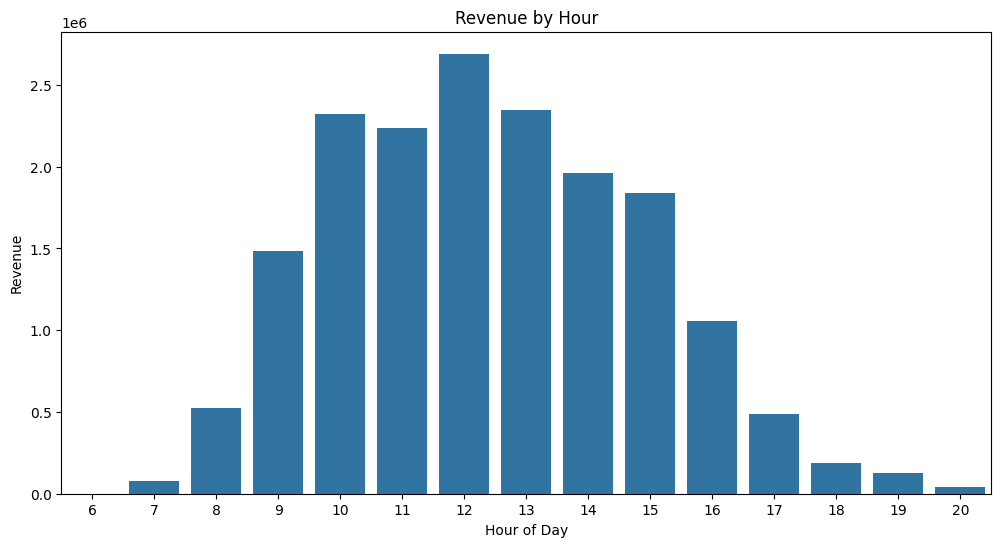

In [33]:
hourly_sales = (
    df.groupby("Hour")["TotalPrice"]
    .sum()
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=hourly_sales.index,
    y=hourly_sales.values
)

plt.title("Revenue by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Revenue")
plt.show()

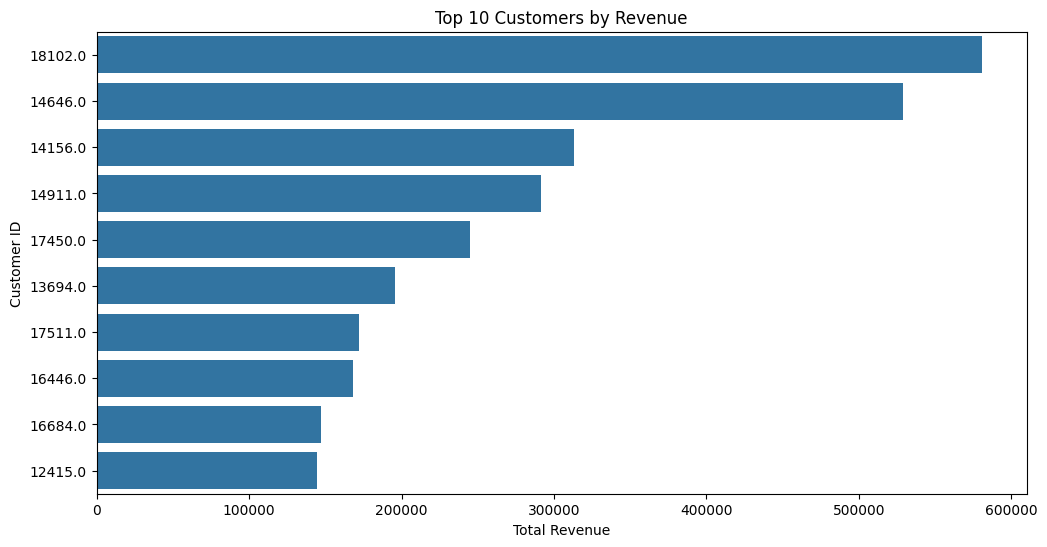

In [34]:
top_customers = (
    df.groupby("CustomerID")["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_customers.values,
    y=top_customers.index.astype(str)
)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Customer ID")
plt.show()

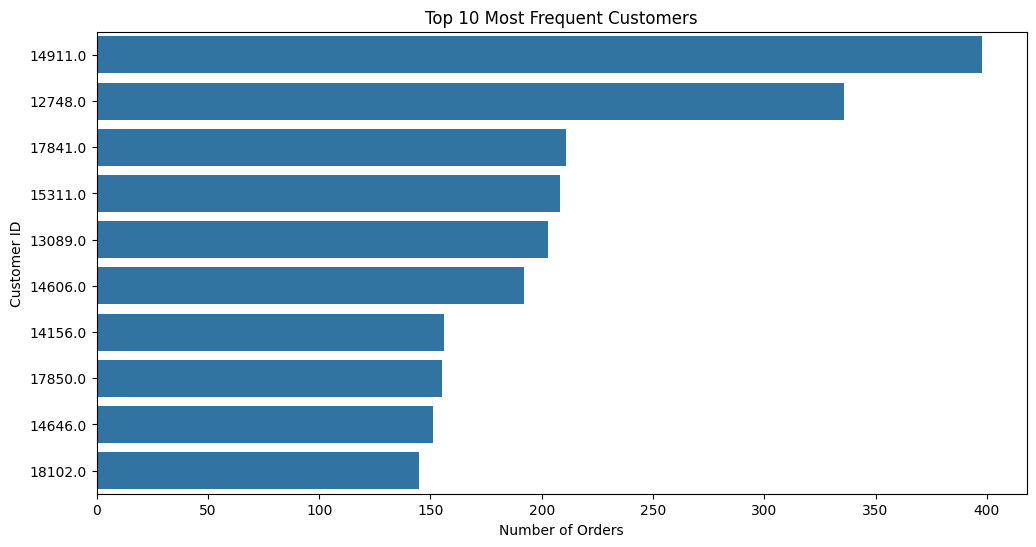

In [35]:
top_frequent_customers = (
    df.groupby("CustomerID")["InvoiceNo"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_frequent_customers.values,
    y=top_frequent_customers.index.astype(str)
)

plt.title("Top 10 Most Frequent Customers")
plt.xlabel("Number of Orders")
plt.ylabel("Customer ID")
plt.show()

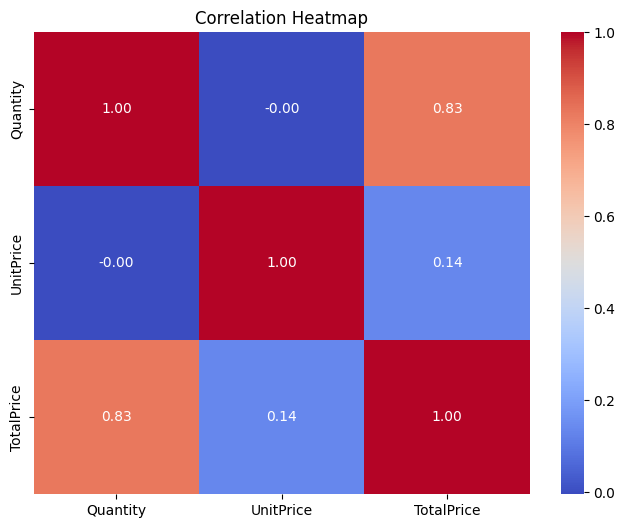

In [36]:
corr = df[["Quantity", "UnitPrice", "TotalPrice"]].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()


In [38]:
df.to_csv(r"E:\RetailPulse_Project\data\cleaned\online_retail_eda_ready_big.csv", index=False)